In [1]:
import numpy as np
import pandas as pd
df=pd.read_csv("../dataset/creditcard.csv")
df=df.drop_duplicates()

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Time'] = scaler.fit_transform(df[['Time']])
df['Amount'] = scaler.fit_transform(df[['Amount']])

In [3]:
from sklearn.model_selection import train_test_split
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)


(226980, 30)
(56746, 30)


In [4]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_pred_lr))

Accuracy: 0.9991365030134283
Precision: 0.8484848484848485
Recall: 0.5894736842105263
F1 Score: 0.6956521739130435
ROC AUC: 0.7946485824099356


In [6]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
    n_estimators=100,
    random_state=42,
)

rf.fit(X_train,y_train)

y_pred_rf=rf.predict(X_test)

In [7]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_pred_rf))

Accuracy: 0.9995065731505305
Precision: 0.971830985915493
Recall: 0.7263157894736842
F1 Score: 0.8313253012048193
ROC AUC: 0.8631402427977767


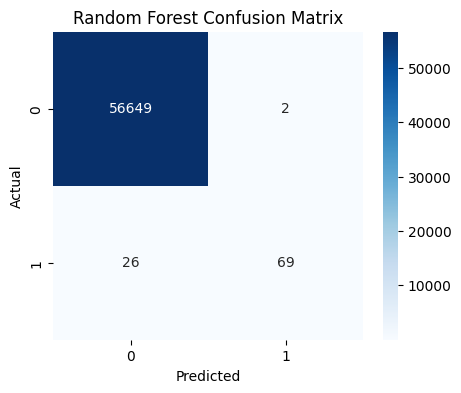

In [8]:
import matplotlib.pyplot as plt 
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [9]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
17,V17,0.156630
14,V14,0.135815
12,V12,0.130210
10,V10,0.087668
16,V16,0.072663
11,V11,0.050887
9,V9,0.033644
18,V18,0.031955
4,V4,0.025765
7,V7,0.024406


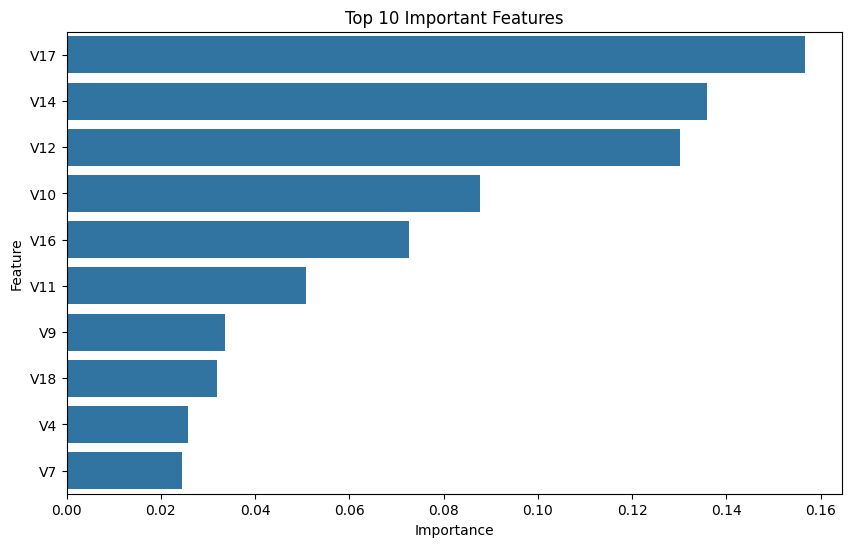

In [10]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()